# Task 1 - Regression

For this task you are given a dataset containing the amount spent towards advertising about a product on TV in different regions of the world and the amount of sales revenue generated from selling that product in the corresponding region. The finance department wants to analyze if there was any benefit to running this ad campaign and have tasked you with determining if there was any correlation between the advertisements and sales revenue generated. To this extent, they have suggested that you run a simple linear regression analysis on the data and through visual representation depict if there was any correlation or not. 

Given:
- I have a dataset (data_df) amount spent on advertisement on TV in diff regions/ sales revenue within that region


Action:
- Check for benefits to running the ad in that region

Approach
- Run a simple lin reg analysis and use visual representation to depict correlation

Goal:
- Show if there's correlation or not

Complete the following tasks for grading - 
- **(5 points)** Read and plot the dataset 

- **(10 points)** Split the dataset into training (first 150 rows) and testing (last 50 rows) data
- **(10 points)** Fit a simple linear regression model on the training data 
- **(10 points)** Predict the sales revenue using the testing data 
- **(10 points)** Compute the root mean squared error of the predicted values
- **(5 points)** Display the line of best fit across the entire dataset
---

In [59]:
# Import python packages as needed. Add your import statements in this block if you need more packages
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

**Read the dataset into a pandas dataframe**

In [70]:
# Read regression dataset
data_df = pd.read_csv('../data/regression_data.csv')
data_df.describe()
print(data_df.head())


      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


**Plot the dataset as a scatter plot to visualize**

<Axes: title={'center': 'TV Advertisement Cost vs Sales'}, xlabel='TV', ylabel='Sales'>

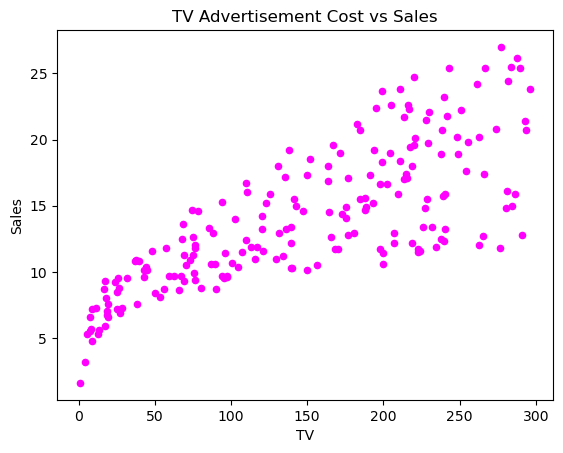

In [72]:
# Add code here (you may add more cells as you need)
data_df.plot.scatter(x='TV', y='Sales', title='TV Advertisement Cost vs Sales', color='fuchsia')


**Split the dataset into training and testing sets**

Use the first 150 rows as training data and the last 50 rows as testing data. Remember that when you are creating a testing dataset, you must separate the features from the target in the data i.e. separate the X (TV advertisement cost) and the Y (Sales Revenue Generated).

In [62]:
# Add code here (you may add more cells as you need)
from sklearn.model_selection import train_test_split

#Split the first 150(0-149) rows as training
#tv is the feature and sales is the target variable 
#We're looking to predict sales based on advert cost (TV)

trainX_df = data_df.iloc[:150][['TV']] #advert cost
trainY_df = data_df.iloc[:150]['Sales'] #sales revernue 

#split the last 50(150-199) rows as testing  
testX_df = data_df.iloc[150:200][['TV']] #advert cost
testY_df = data_df.iloc[150:200]['Sales']   #sales revenue

print(trainX_df.head(),trainY_df.head())
print(testX_df.head(), testY_df.head())

      TV
0  230.1
1   44.5
2   17.2
3  151.5
4  180.8 0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64
        TV
150  280.7
151  121.0
152  197.6
153  171.3
154  187.8 150    16.1
151    11.6
152    16.6
153    19.0
154    15.6
Name: Sales, dtype: float64


**Fit a simple linear regression model on the training data**

You may use any python package to do this task (sklearn, statsmodels and so on) or you may write your own code to compute the simple linear regression model coefficients.

In [63]:
# Add code here (you may add more cells as you need)
from sklearn.linear_model import LinearRegression
#empty model
model = LinearRegression()

#use x and y to find line of best fit
model.fit(trainX_df, trainY_df)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Use the trained simple linear regression model to predict on the testing data**

In [64]:
# Add code here (you may add more cells as you need)
#in tv advert cost, out predicted sales revenue
predictions = model.predict(testX_df)
#predicted 
print(predictions[:5])
#actual
print(testY_df[:5])

[20.88268261 13.04734061 16.80555725 15.5152035  16.32474102]
150    16.1
151    11.6
152    16.6
153    19.0
154    15.6
Name: Sales, dtype: float64


**Compute and display the root mean squared error on the predicted data**

In [65]:
# Add code here (you may add more cells as you need)
#how off is the model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(testY_df, predictions)
print("Mean Squared Error:", mse)

#MSE: The diff between the real and predicted sales squared so negatives dont cancle out postivies. Then the average of that
#MSE:  1/n sum (y_i - y_pred_i)^2
root_mse = np.sqrt(mse)
print("Root Mean Squared Error:", root_mse)

Mean Squared Error: 13.17474734816032
Root Mean Squared Error: 3.629703479371327


The model has an MSE of 13, corresponding to an RMSE of 3.6 which shows that the predictions from the model are off about 3-4 units. Using what I learned from DATASCI 110, while TV advert can be a meaningful predictor of sales there could be a confounder contributing to the remaining error.

**Plot the line of best fit on the entire dataset**

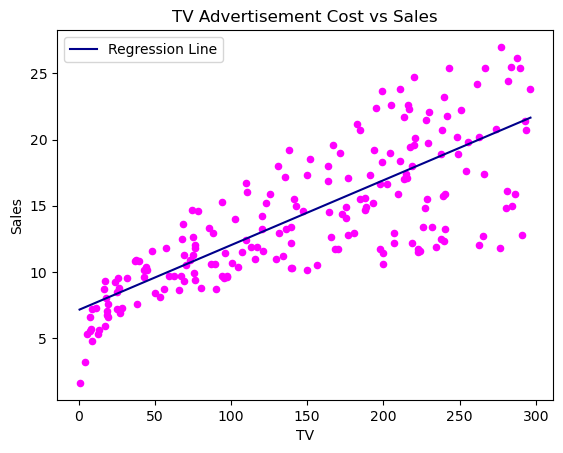

In [76]:
# Add code here (you may add more cells as you need)
ax = data_df.plot.scatter(x='TV', y='Sales', title='TV Advertisement Cost vs Sales', color='fuchsia')
sorted_data = data_df.sort_values(by='TV')
ax.plot(sorted_data['TV'], model.predict(sorted_data[['TV']]), color='darkblue', label='Regression Line')
ax.legend()
plt.show()

---